<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 11 <a name="PII511"></a>

Considere o campo de deslocamentos de um objeto dada por (unidades em mm):

\begin{equation*}
    \vec{u} = k(x^2 + y^2 + 2) \vec\imath +
    k(3x + 4y^2) \vec\jmath + k(2x^2 + 4z) \vec{k} \quad\textrm{com}\quad k= 10^{-4}
\end{equation*}

[(a)](#A) Determine o vetor posição de um ponto $P'$ cujas coordenadas iniciais são $P(1,2,3)$.

[(b)](#B) Determine as componentes de deformação de Lagrange e de deformação infinitesimais no ponto $(1,2,3)$. Discuta a aproximação entre as duas abordagens de acordo com o parâmetro $k$.


## Resolução

#### a) Determine o vetor posição de um ponto $P'$ cujas coordenadas iniciais são $P(1,2,3)$.<a name="A"></a>
([enunciatum](#PII511))

O estudo da deformação ou da mudança de forma de um corpo, tipicamente envolve a comparação das posições de pontos materiais ao longo da evolução da deformação, nomeadamente entre dois instantes, antes (configuração de referência) e depois (configuração atual) deformação, gerada por exemplo, por solicitação mecânica.

Considere-se o ponto material $P$ de um corpo com coordenadas cartesiandas $(x,y,z)$ em relação a um sistema de coordenadas $S$, arbitrariamente escolhido, e inicialmente em repouso (configuração de referência). Após deformação (pela aplicação de forças externas, de superfície ou volume) o ponto $P'$ passará a ocupar uma região do espaço definida em $S$ pelas coordenadas $(x',y',z')$ (configuração atual).

Uma vez que a transformação ou aplicação desloca o ponto $P$ para a nova posição $P'$, ao vetor definido pelo segmento de reta $\overrightarrow{PP'}$ dá-se o nome de vetor deslocamento, $\underline{u} = \vec{u}$. O vetor de deslocamento tem as componentes $u_x  \equiv u$, $u_y \equiv v$ e $u_z \equiv w$ ao longo dos eixos $x$, $y$ e $z$, respectivamente:

\begin{equation*}
\vec{u} = u \vec{\imath} + v \vec{\jmath} + w \vec{k}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P011_1.jpg"
width="400" height="230">

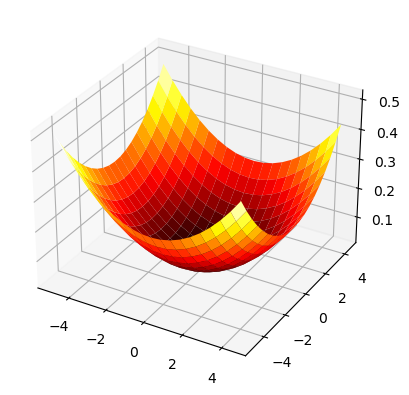

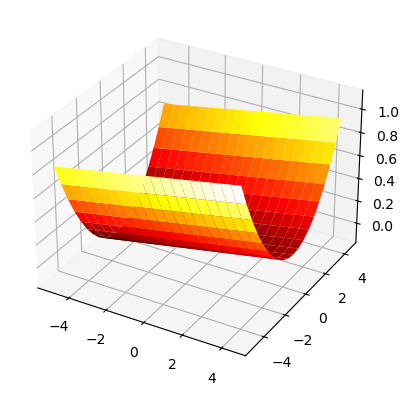

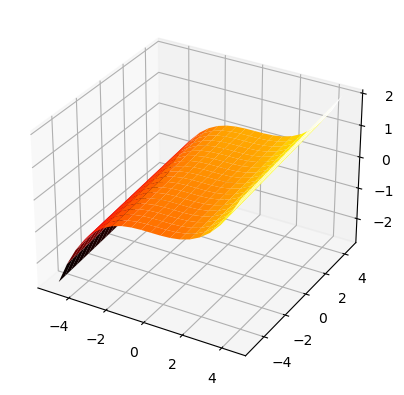

In [23]:
import numpy as np
from sympy import diff
from sympy import symbols
import matplotlib.pyplot as plt
from pylab import cm,imshow,colorbar,title

u, v, w, x, y, z, k = symbols('u v w x y z k')

def u(x,y,k): return k*(x**2 + y**2 + 2)
def v(x,y,k): return k*(3*x + 4*y**2)
def w(x,z,k): return k*(2*x**3 + 4*z)

xgrid = np.arange(-5.,5,.5); ygrid = xgrid; zgrid = xgrid
Xu,Yu = np.meshgrid(xgrid, ygrid) # grid of point
Xv,Yv = np.meshgrid(xgrid, ygrid)
Xw,Zw = np.meshgrid(xgrid, zgrid)

def PlotFig(X,Y,Z,stg,fTyp):
    if fTyp == 0:
        plt.figure(111)
        colorbar(imshow(Z,cmap=cm.hot))
        title(stg), plt.axis('off')
        plt.show()
    else:
        fig = plt.figure(121)
        ax = fig.add_subplot(111, projection='3d')
        cset = ax.plot_surface(X,Y,Z, cmap=cm.hot)
        ax.clabel(cset, fontsize=9, inline=1)
        plt.show()

kn = 1e-2
PlotFig(Xu,Yu,u(Xu,Yu,kn),['u = ',u(x,y,k)],1)
PlotFig(Xv,Yv,v(Xv,Yv,kn),['v = ',v(x,y,k)],1)
PlotFig(Xw,Zw,w(Xw,Zw,kn),['w = ',w(x,z,k)],1)

Representando por $\vec{r}$ e $\vec{r}'$ os vetores posição de $P$ e $P'$, respetivamente, então:

\begin{equation*}
\begin{aligned}
\vec{r}' &= \vec{r} + \vec{u} \\
\vec{u} &= \vec{r}' - \vec{r} \\
\end{aligned}
\end{equation*}

Na descrição material ou Lagrangeana do movimento, o deslocamento sofrido por um ponto material é uma função de suas coordenadas iniciais: $\vec{u} = \vec{u}(P,t)~,\forall P \in C$. Assume-se também que os deslocamentos são definidos em todo o volume do corpo, i.e., o vetor deslocamento $u$ de qualquer ponto $P$ pertencente ao corpo fica completamente definido (tanto em amplitude como direção) uma vez conhecidas as suas coordenadas posicionais.

In [24]:
u1, v1, w1 = u(x,y,k), v(x,y,k), w(x,z,k)

Px0, Py0, Pz0 = 1, 2, 3
print(f'Posição inicial de P = {Px0,Py0,Pz0}')

u1 = u1.subs({x:Px0,y:Py0,z:Pz0,k:kn})
v1 = v1.subs({x:Px0,y:Py0,z:Pz0,k:kn})
w1 = w1.subs({x:Px0,y:Py0,z:Pz0,k:kn})

Px1 = Px0 + u1
Py1 = Py0 + v1
Pz1 = Pz0 + w1

print(f'Posição final de P = ({Px1:.5f},{Py1:.5f},{Pz1:.5f})')

Posição inicial de P = (1, 2, 3)
Posição final de P = (1.07000,2.19000,3.14000)


#### b) Determine as componentes de deformação de Lagrange e de deformação infinitesimais no ponto $(1,2,3)$.<a name="B"></a>

([enunciatum](#PII511))

**Deformação de Lagrange**

A matriz das deformações de Green ou matriz das deformações de Lagrange, $[E]$ é dada por:
\begin{equation*}
[E] =
\begin{bmatrix}
E_{xx} & G_{xy} & G_{xz} \\
G_{xy} & E_{yy} & G_{yz} \\
G_{xz} & G_{yz} & E_{zz}
\end{bmatrix}
\end{equation*}

com,

\begin{equation*}
\begin{aligned}
E_{xx} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial x}\right)^2 +
\left(\frac{\partial v}{\partial x}\right)^2 + \left(\frac{\partial w}{\partial x}\right)^2\right]\\
E_{yy} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial y}\right)^2 +
\left(\frac{\partial v}{\partial y}\right)^2 + \left(\frac{\partial w}{\partial y}\right)^2\right] \\
E_{zz} & = \frac{\partial u}{\partial x} + \frac{1}{2}\left[ \left(\frac{\partial u}{\partial z}\right)^2 +
\left(\frac{\partial v}{\partial z}\right)^2 + \left(\frac{\partial w}{\partial z}\right)^2\right]\\
G_{xy} & = \frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial x}\frac{\partial u}{\partial y} +
\frac{\partial v}{\partial x}\frac{\partial v}{\partial y} +
\frac{\partial w}{\partial x}\frac{\partial w}{\partial y} \right) \\
G_{xz} & = \frac{1}{2}\left(\frac{\partial u}{\partial z}+\frac{\partial w}{\partial x}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial x}\frac{\partial u}{\partial z} +
\frac{\partial v}{\partial x}\frac{\partial v}{\partial z} +
\frac{\partial w}{\partial x}\frac{\partial w}{\partial z} \right)\\
G_{yz} & = \frac{1}{2}\left(\frac{\partial v}{\partial z}+\frac{\partial w}{\partial y}\right) +
\frac{1}{2} \left( \frac{\partial u}{\partial y}\frac{\partial u}{\partial z} +
\frac{\partial v}{\partial y}\frac{\partial v}{\partial z} +
\frac{\partial w}{\partial y}\frac{\partial w}{\partial z} \right)\\
\end{aligned}
\end{equation*}

A deformação de Lagrange num determinado ponto $P$ e numa dada direção definida pelo versor $\vec{n}$ vem:

\begin{equation*}
E = \underline{n}^\mathrm{T}\underline{\underline{E}}\,\underline{n} = n_i E_{ij} n_j
\end{equation*}

Representando por $l, m, n$ as componentes do versor $\vec{n}$ no sitema de coordenadas
$S(0,\vec{\imath},\vec{\jmath},\vec{k})$, a expressão anterior resulta explicitamente em:

\begin{equation*}
E = E_{xx}l^2 + E_{yy}m^2 + E_{zz}n^2 + 2G_{xy}lm + 2G_{yz}mn + 2G_{xz}ln
\end{equation*}

In [25]:
u1 = u(x,y,k)
v1 = v(x,y,k)
w1 = w(x,z,k)

print('\nMatriz das deformações de Lagrane [E] :')

# componentes cartesianas da matriz das deformações de Green-Lagrange
Exx = diff(u1, x) + 0.5*(diff(u1, x)**2 + diff(v1, x)**2 + diff(w1, x)**2)
print('\nExx :',Exx)
Eyy = diff(v1, y) + 0.5*(diff(u1, y)**2 + diff(v1, y)**2 + diff(w1, y)**2)
print('Eyy :',Eyy)
Ezz = diff(w1, z) + 0.5*(diff(u1, z)**2 + diff(v1, z)**2 + diff(w1, z)**2)
print('Ezz :',Ezz)
Gxy = 0.5*(diff(u1, y) + diff(v1, x)) + 0.5*(diff(u1,x)*diff(u1,y) + diff(v1,x)*diff(v1,y) + diff(w1,x)*diff(w1,y))
print('Gxy :',Gxy)
Gxz = 0.5*(diff(u1, z) + diff(w1, x)) + 0.5*(diff(u1,x)*diff(u1,z) + diff(v1,x)*diff(v1,z) + diff(w1,x)*diff(w1,z))
print('Gxz :',Gxz)
Gyz = 0.5*(diff(v1, z) + diff(w1, y)) + 0.5*(diff(u1,y)*diff(u1,z) + diff(v1,y)*diff(v1,z) + diff(w1,y)*diff(w1,z))
print('Gyz :',Gyz)

def mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz):
    return np.array([[Exx,Gxy,Gxz],[Gxy,Eyy,Gyz],[Gxz,Gyz,Ezz]])

mE0 = mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz)
print('\n[E] = \n',mE0)

Exx = float(Exx.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
Eyy = float(Eyy.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
Ezz = float(Ezz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
Gxy = float(Gxy.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
Gxz = float(Gxz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
Gyz = float(Gyz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))


print('\nComponentes da deformação de Lagrange no ponto P:')
print(' Exx = ','{:.5f}'.format(Exx))
print(' Eyy = ','{:.5f}'.format(Eyy))
print(' Ezz = ','{:.5f}'.format(Ezz))
print(' Gxy = ','{:.5f}'.format(Gxy))
print(' Gxz = ','{:.5f}'.format(Gxz))
print(' Gyz = ','{:.5f}'.format(Gyz))

mEP = mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz)
np.set_printoptions(formatter={'float': '{: 0.6f}'.format})
print('\n[E(P)] = \n',mEP)


Matriz das deformações de Lagrane [E] :

Exx : 18.0*k**2*x**4 + 2.0*k**2*x**2 + 4.5*k**2 + 2*k*x
Eyy : 34.0*k**2*y**2 + 8*k*y
Ezz : 8.0*k**2 + 4*k
Gxy : 2.0*k**2*x*y + 12.0*k**2*y + 1.0*k*y + 1.5*k
Gxz : 12.0*k**2*x**2 + 3.0*k*x**2
Gyz : 0

[E] = 
 [[18.0*k**2*x**4 + 2.0*k**2*x**2 + 4.5*k**2 + 2*k*x
  2.0*k**2*x*y + 12.0*k**2*y + 1.0*k*y + 1.5*k
  12.0*k**2*x**2 + 3.0*k*x**2]
 [2.0*k**2*x*y + 12.0*k**2*y + 1.0*k*y + 1.5*k 34.0*k**2*y**2 + 8*k*y 0]
 [12.0*k**2*x**2 + 3.0*k*x**2 0 8.0*k**2 + 4*k]]

Componentes da deformação de Lagrange no ponto P:
 Exx =  0.02245
 Eyy =  0.17360
 Ezz =  0.04080
 Gxy =  0.03780
 Gxz =  0.03120
 Gyz =  0.00000

[E(P)] = 
 [[ 0.022450  0.037800  0.031200]
 [ 0.037800  0.173600  0.000000]
 [ 0.031200  0.000000  0.040800]]


**Deformação infinitesimal**

Considerando um estado de deformação infinitesimal: $E \approx \varepsilon$, e desprezando portanto os termos de ordem superior, resultam as seguintes componentes do tensor das deformações infinitésimais:

\begin{equation*}
\varepsilon_{ij} = \frac{1}{2}\left( \frac{\partial u_i}{\partial x_j}
+ \frac{\partial u_j}{\partial x_i} \right)
\end{equation*}

Explicitamente:

\begin{equation*}
\begin{aligned}
\varepsilon_{xx} &= \frac{\partial u}{\partial x} \\
\varepsilon_{yy} &= \frac{\partial v}{\partial y} \\
\varepsilon_{zz} &= \frac{\partial w}{\partial z} \\
\varepsilon_{xy} &= \frac{1}{2}\left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)  = \frac{1}{2}\gamma_{xy}\\
\varepsilon_{yz} &= \frac{1}{2}\left( \frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)  = \frac{1}{2} \gamma_{yz}\\
\varepsilon_{xz} &= \frac{1}{2}\left( \frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) = \frac{1}{2} \gamma_{xz}\\
\end{aligned}
\end{equation*}

A extensão na direção definida pelo versor $\vec{n}$ vem:

\begin{equation*}
\varepsilon^{(\vec{n})} = \underline{n}^\mathrm{T}[D]\underline{n}
\end{equation*}

In [26]:
print('Matriz das deformações infinitesimal, [D] :')

# componentes cartesianas da matriz das deformações
exx = diff(u1, x)
print('\nexx = du\\dx :',exx)
eyy = diff(v1, y)
print('eyy = dv\\dy :',eyy)
ezz = diff(w1, z)
print('ezz = dw\\dz :',ezz)
exy  = 0.5*(diff(u1, y) + diff(v1, x) )
print('exy = 1\\2 gxy = 1\\2 (du\\dy + dv\\dx )  :',exy)
exz  = 0.5*(diff(u1, z) + diff(w1, x) )
print('exz = 1\\2 gxz = 1\\2 (du\\dz + dw\\dx )  :',exz)
eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
print('eyz = 1\\2 gxy = 1\\2 (dv\\dz + dw\\dy )  :',eyz)

def mD(exx,exy,exz,eyy,eyz,ezz):
    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

mD0 = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[D] =\n',mD0)

exx = float(exx.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
eyy = float(eyy.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
ezz = float(ezz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
exy = float(exy.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
exz = float(exz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
eyz = float(eyz.subs({x:Px0,y:Py0,z:Pz0,k:kn}))
gxy = 2*exy
gxz = 2*exz
gyz = 2*eyz

print('\nComponentes de deformação infinitesimal no ponto P:')
print('\n exx = ','{:.5f}'.format(exx))
print(' eyy = ','{:.5f}'.format(eyy))
print(' ezz = ','{:.5f}'.format(ezz))
print(' gxy = ','{:.5f}'.format(gxy))
print(' gxz = ','{:.5f}'.format(gxz))
print(' gyz = ','{:.5f}'.format(gyz))

mDP = mD(exx,exy,exz,eyy,eyz,ezz)
print('\n[D(P)] = \n',mDP)

Matriz das deformações infinitesimal, [D] :

exx = du\dx : 2*k*x
eyy = dv\dy : 8*k*y
ezz = dw\dz : 4*k
exy = 1\2 gxy = 1\2 (du\dy + dv\dx )  : 1.0*k*y + 1.5*k
exz = 1\2 gxz = 1\2 (du\dz + dw\dx )  : 3.0*k*x**2
eyz = 1\2 gxy = 1\2 (dv\dz + dw\dy )  : 0

[D] =
 [[2*k*x 1.0*k*y + 1.5*k 3.0*k*x**2]
 [1.0*k*y + 1.5*k 8*k*y 0]
 [3.0*k*x**2 0 4*k]]

Componentes de deformação infinitesimal no ponto P:

 exx =  0.02000
 eyy =  0.16000
 ezz =  0.04000
 gxy =  0.07000
 gxz =  0.06000
 gyz =  0.00000

[D(P)] = 
 [[ 0.020000  0.035000  0.030000]
 [ 0.035000  0.160000  0.000000]
 [ 0.030000  0.000000  0.040000]]


Discutindo a avaliação das componentes de deformação pela formulação de Lagrange e infinitesimal no ponto $(1,2,3)$ para diferentes valores de $k$:

In [27]:
np.set_printoptions(formatter={'float': '{: 6.4e}'.format})

def Lagrk(vark):

    # componentes cartesianas da matriz das deformações de Green-Lagrange
    Exx = diff(u1, x) + 0.5*(diff(u1, x)**2 + diff(v1, x)**2 + diff(w1, x)**2)
    Eyy = diff(v1, y) + 0.5*(diff(u1, y)**2 + diff(v1, y)**2 + diff(w1, y)**2)
    Ezz = diff(w1, z) + 0.5*(diff(u1, z)**2 + diff(v1, z)**2 + diff(w1, z)**2)
    Gxy = 0.5*(diff(u1, y) + diff(v1, x)) + 0.5*(diff(u1,x)*diff(u1,y) + diff(v1,x)*diff(v1,y) + diff(w1,x)*diff(w1,y))
    Gxz = 0.5*(diff(u1, z) + diff(w1, x)) + 0.5*(diff(u1,x)*diff(u1,z) + diff(v1,x)*diff(v1,z) + diff(w1,x)*diff(w1,z))
    Gyz = 0.5*(diff(v1, z) + diff(w1, y)) + 0.5*(diff(u1,y)*diff(u1,z) + diff(v1,y)*diff(v1,z) + diff(w1,y)*diff(w1,z))

    Exx = float(Exx.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    Eyy = float(Eyy.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    Ezz = float(Ezz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    Gxy = float(Gxy.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    Gxz = float(Gxz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    Gyz = float(Gyz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))

    mEP = mE(Exx,Gxy,Gxz,Eyy,Gyz,Ezz)
    print(mEP)
    return mEP

def Dinf(vark):

    # componentes cartesianas da matriz das deformações
    exx = diff(u1, x)
    eyy = diff(v1, y)
    ezz = diff(w1, z)
    exy  = 0.5*(diff(u1, y) + diff(v1, x) )
    exz  = 0.5*(diff(u1, z) + diff(w1, x) )
    eyz  = 0.5*(diff(v1, z) + diff(w1, y) )
    exx = float(exx.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    eyy = float(eyy.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    ezz = float(ezz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    exy = float(exy.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    exz = float(exz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    eyz = float(eyz.subs({x:Px0,y:Py0,z:Pz0,k:vark}))
    mDP = mD(exx,exy,exz,eyy,eyz,ezz)
    print(mDP)
    return mDP


In [28]:
knew = 1
print('----------------------------------')
print(f'k = {knew} (grandes deformações)')
print('----------------------------------')
print('Deformação de Lagrange, E(P):')
D1 = Lagrk(knew)
print('\nDeformação infinitesimal, D(P):')
D2 = Dinf(knew)
print(f'\nexx dif = {(D2[0,0]-D1[0,0])/D1[0,0]*100:5.2f} %')

----------------------------------
k = 1 (grandes deformações)
----------------------------------
Deformação de Lagrange, E(P):
[[ 2.6500e+01  3.1500e+01  1.5000e+01]
 [ 3.1500e+01  1.5200e+02  0.0000e+00]
 [ 1.5000e+01  0.0000e+00  1.2000e+01]]

Deformação infinitesimal, D(P):
[[ 2.0000e+00  3.5000e+00  3.0000e+00]
 [ 3.5000e+00  1.6000e+01  0.0000e+00]
 [ 3.0000e+00  0.0000e+00  4.0000e+00]]

exx dif = -92.45 %


In [29]:
knew = 1e-4
print('----------------------------------')
print(f'k = {knew} (pequenas deformações)')
print('----------------------------------')
print('Deformação de Lagrange, E(P):')
D1 = Lagrk(knew)
print('\nDeformação infinitesimal, D(P):')
D2 = Dinf(knew)
print(f'\nexx dif = {(D2[0,0]-D1[0,0])/D1[0,0]*100:5.2f} %')

----------------------------------
k = 0.0001 (pequenas deformações)
----------------------------------
Deformação de Lagrange, E(P):
[[ 2.0025e-04  3.5028e-04  3.0012e-04]
 [ 3.5028e-04  1.6014e-03  0.0000e+00]
 [ 3.0012e-04  0.0000e+00  4.0008e-04]]

Deformação infinitesimal, D(P):
[[ 2.0000e-04  3.5000e-04  3.0000e-04]
 [ 3.5000e-04  1.6000e-03  0.0000e+00]
 [ 3.0000e-04  0.0000e+00  4.0000e-04]]

exx dif = -0.12 %


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

